# 📊 Análisis Avanzado de Airbnb: Procesamiento y Exploración

Este notebook detalla el proceso de carga, limpieza y análisis exploratorio de un dataset de Airbnb. 
El objetivo es identificar patrones de precios y calidad de datos para futuros modelos predictivos.

---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display, HTML

# Configuración de estilos visuales
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Función utilitaria para encabezados coloridos y visibles
def mostrar_titulo(texto, color="#2c3e50", subrayado="#3498db"):
    """Muestra un título elegante usando HTML para mejorar la legibilidad del análisis."""
    display(HTML(f"""
        <div style='border-left: 10px solid {subrayado}; 
                    background-color: #f8f9fa; 
                    padding: 15px; 
                    margin: 20px 0; 
                    border-radius: 4px;'>
            <h2 style='color: {color}; margin: 0; font-family: Segoe UI, Arial, sans-serif;'>{texto}</h2>
        </div>
    """))

In [3]:
# Carga de la base de datos
ruta_archivo = 'train.csv'

try:
    df = pd.read_csv(ruta_archivo)
    mostrar_titulo("Datos cargados exitosamente", color="#1e8449", subrayado="#2ecc71")
    print(f"El dataset contiene {df.shape[0]} registros y {df.shape[1]} columnas.")
    display(df.head())
except FileNotFoundError:
    print("Error: No se encontró el archivo train.csv")

El dataset contiene 74111 registros y 29 columnas.


,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,...,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,...,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,...,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117.0,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,...,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0


### Parte 2: Análisis Exploratorio de Datos (EDA)

#### Análisis descriptivo
Calcula estadísticas para cada variable (media, mediana, desviación estándar, etc.). Identifica las variables que podrían influir más en el precio de una vivienda.

### 🔍 Inspección Estructural del Dataset
Comenzamos explorando la arquitectura de los datos: dimensiones y tipos de variables.


In [4]:
mostrar_titulo("1.1 ESTRUCTURA GENERAL", subrayado="#3498db")
df.info()
print(f"\n📐 Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")


<class 'pandas.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      74111 non-null  int64  
 1   log_price               74111 non-null  float64
 2   property_type           74111 non-null  str    
 3   room_type               74111 non-null  str    
 4   amenities               74111 non-null  str    
 5   accommodates            74111 non-null  int64  
 6   bathrooms               73911 non-null  float64
 7   bed_type                74111 non-null  str    
 8   cancellation_policy     74111 non-null  str    
 9   cleaning_fee            74111 non-null  bool   
 10  city                    74111 non-null  str    
 11  description             74111 non-null  str    
 12  first_review            58247 non-null  str    
 13  host_has_profile_pic    73923 non-null  str    
 14  host_identity_verified  73923 non-null  str    
 

### 🏷️ Clasificación de Variables
Separamos las variables constantes de las numéricas para orientar las transformaciones futuras.


In [5]:
num_cols = df.select_dtypes(include=['number']).columns.tolist()
cat_cols = df.select_dtypes(exclude=['number']).columns.tolist()
mostrar_titulo("1.2 TIPOS DEDATOS", subrayado="#3498db")
print(f"🔢 Numéricas: {len(num_cols)} | 🏷️ Categóricas: {len(cat_cols)}")


🔢 Numéricas: 10 | 🏷️ Categóricas: 19


### 📈 Análisis Estadístico Descriptivo
Observamos las tendencias centrales y la dispersión de los datos para entender la escala de los precios y servicios.


In [6]:
mostrar_titulo("1.3 ESTADÍSTICAS NUMÉRICAS", subrayado="#9b59b6")
display(df.describe().T)


,count,mean,std,min,25%,50%,75%,max
id,74111.0,1.126662e+07,6.081735e+06,344.000000,6.261964e+06,1.225415e+07,1.640226e+07,2.123090e+07
log_price,74111.0,4.782069e+00,7.173938e-01,0.000000,4.317488e+00,4.709530e+00,5.220356e+00,7.600402e+00
accommodates,74111.0,3.155146e+00,2.153589e+00,1.000000,2.000000e+00,2.000000e+00,4.000000e+00,1.600000e+01
bathrooms,73911.0,1.235263e+00,5.820441e-01,0.000000,1.000000e+00,1.000000e+00,1.000000e+00,8.000000e+00
latitude,74111.0,3.844596e+01,3.080167e+00,33.338905,3.412791e+01,4.066214e+01,4.074610e+01,4.239044e+01
longitude,74111.0,-9.239753e+01,2.170532e+01,-122.511500,-1.183424e+02,-7.699696e+01,-7.395466e+01,-7.098505e+01
number_of_reviews,74111.0,2.090057e+01,3.782864e+01,0.000000,1.000000e+00,6.000000e+00,2.300000e+01,6.050000e+02
review_scores_rating,57389.0,9.406736e+01,7.836556e+00,20.000000,9.200000e+01,9.600000e+01,1.000000e+02,1.000000e+02
bedrooms,74020.0,1.265793e+00,8.521435e-01,0.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+01
beds,73980.0,1.710868e+00,1.254142e+00,0.000000,1.000000e+00,1.000000e+00,2.000000e+00,1.800000e+01


### ⚠️ Calidad de Datos: Valores Faltantes
Identificamos las brechas de información. Variables como 'review_scores' o 'host_response' suelen tener nulos significativos.


In [10]:
mostrar_titulo("1.4 DATOS FALTANTES", subrayado="#e67e22")
missing = df.isnull().sum()
display(pd.DataFrame({'Nulos': missing, '%': (missing/len(df)*100).round(2)}).query('Nulos > 0').sort_values('Nulos', ascending=False))


,Nulos,%
host_response_rate,18299,24.69
review_scores_rating,16722,22.56
first_review,15864,21.41
last_review,15827,21.36
thumbnail_url,8216,11.09
neighbourhood,6872,9.27
zipcode,966,1.30
bathrooms,200,0.27
host_has_profile_pic,188,0.25
host_identity_verified,188,0.25


### 🎯 La Variable Objetivo: log_price
Analizamos la distribución del precio logarítmico para detectar sesgos y outliers que puedan afectar el entrenamiento del modelo.


In [11]:
mostrar_titulo("1.5 ANÁLISIS DE PRECIOS", subrayado="#e74c3c")
Q1, Q3 = df['log_price'].quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = df[(df['log_price'] < (Q1 - 1.5*IQR)) | (df['log_price'] > (Q3 + 1.5*IQR))]
print(f"Outliers detectados: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
print(f"Asimetría: {df['log_price'].skew():.4f} | Curtosis: {df['log_price'].kurtosis():.4f}")


Outliers detectados: 1532 (2.07%)
Asimetría: 0.5147 | Curtosis: 0.6606


# 📈 Visualización y Análisis de Patrones
En esta sección transformamos los números en insights visuales. 
Analizaremos la distribución de precios, la influencia de la ubicación y el impacto del tipo de propiedad.


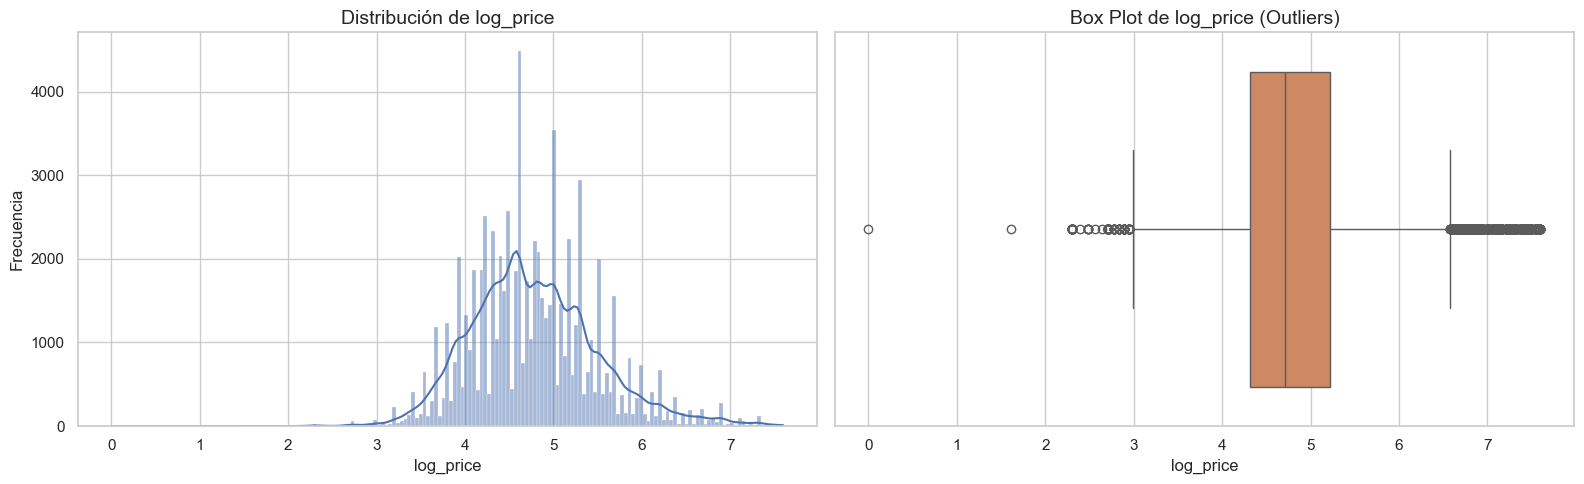

/var/folders/xk/wz3_h0px44q99n7y2rgntp3r0000gn/T/ipykernel_51909/3851168353.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='room_type', y='log_price', palette='Set2')


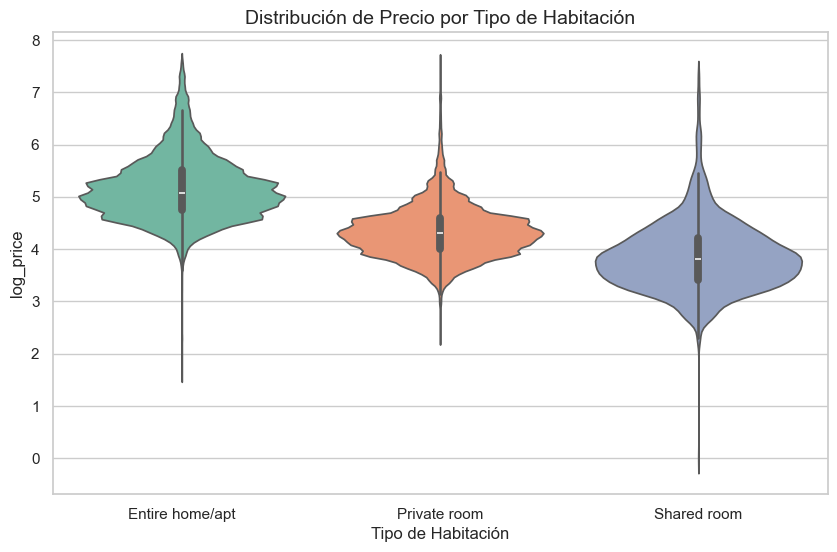

/var/folders/xk/wz3_h0px44q99n7y2rgntp3r0000gn/T/ipykernel_51909/3851168353.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='city', y='log_price', order=city_order, palette='viridis')


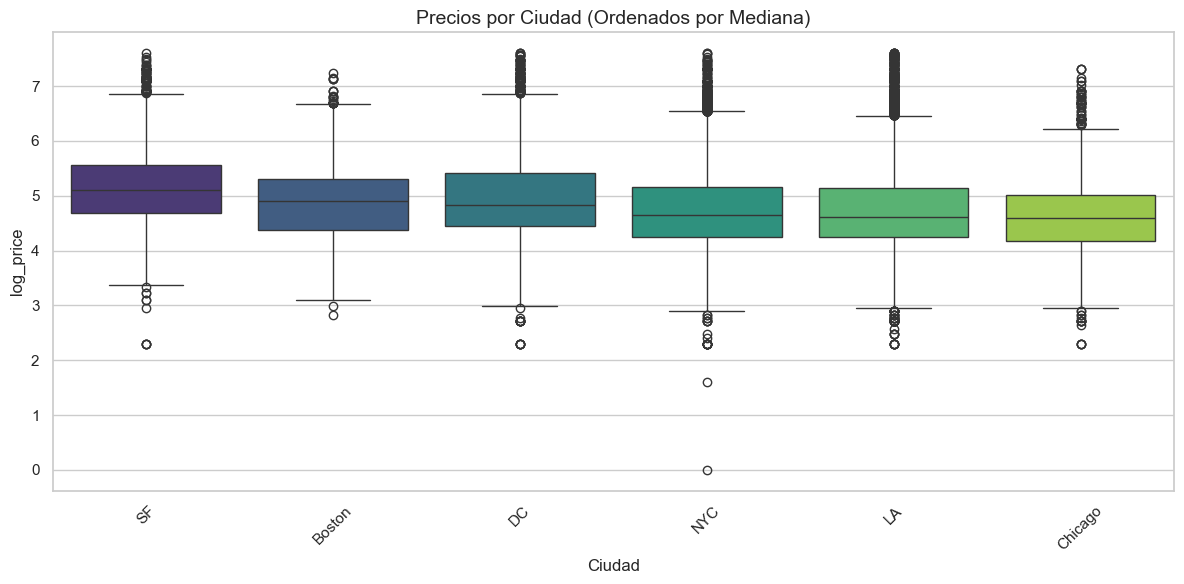

/var/folders/xk/wz3_h0px44q99n7y2rgntp3r0000gn/T/ipykernel_51909/3851168353.py:51: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=df, x='accommodates', y='log_price', ci='sd')


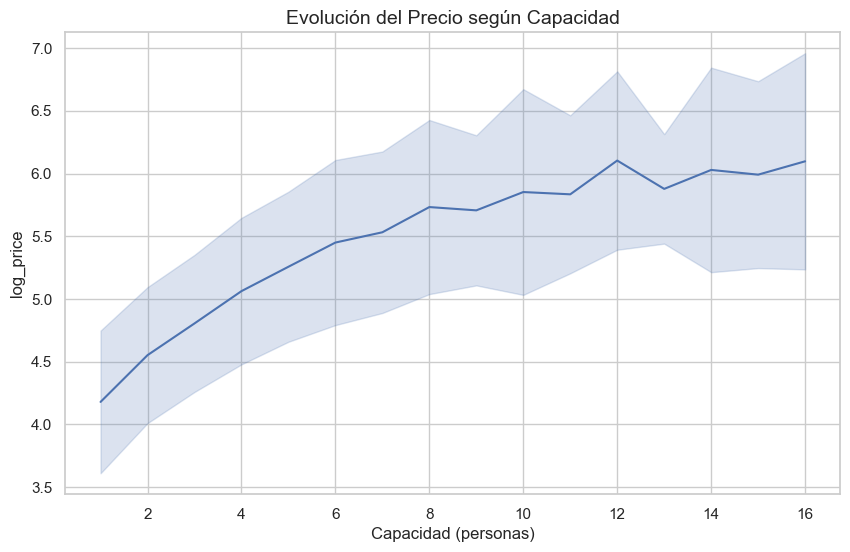

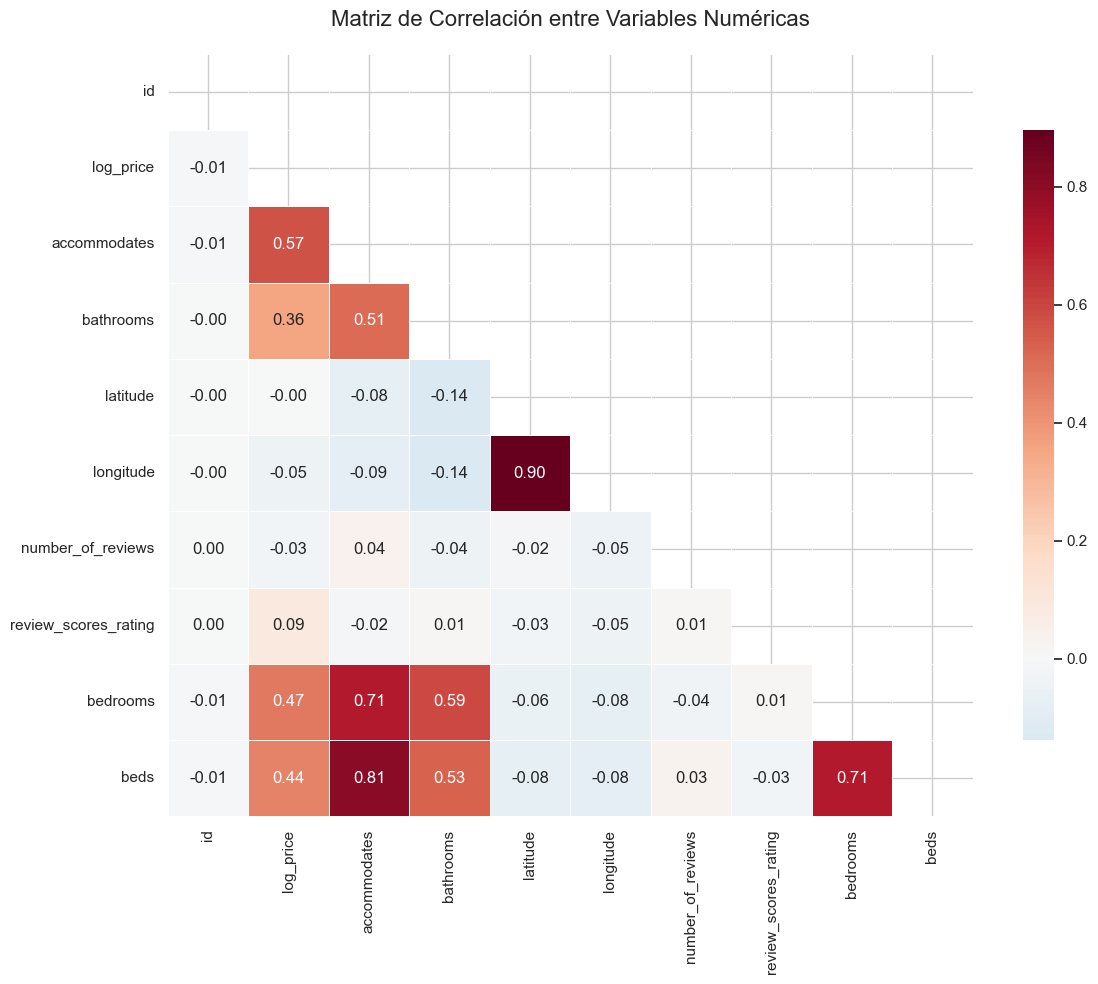


TOP Variables más correlacionadas con log_price:


,Correlación
accommodates,0.567574
bedrooms,0.473212
beds,0.442153
bathrooms,0.355420
review_scores_rating,0.091219
latitude,-0.002193
id,-0.007178
number_of_reviews,-0.032470
longitude,-0.047529


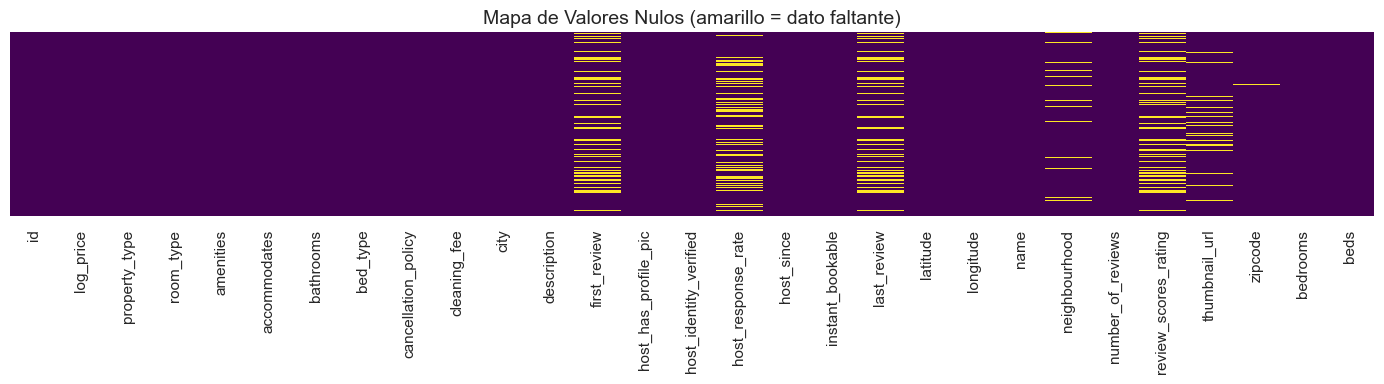

In [12]:
# =============================================
# SECCIÓN 2: VISUALIZACIÓN DE DATOS (Gráficas)
# =============================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# --- 2.1 Distribución de log_price + Box Plot ---
mostrar_titulo("2.1 DISTRIBUCIÓN DE log_price")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(df['log_price'], kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribución de log_price', fontsize=14)
axes[0].set_xlabel('log_price')
axes[0].set_ylabel('Frecuencia')

sns.boxplot(x=df['log_price'], ax=axes[1], color='#DD8452')
axes[1].set_title('Box Plot de log_price (Outliers)', fontsize=14)
axes[1].set_xlabel('log_price')
plt.tight_layout()
plt.show()

# --- 2.2 Precio por Tipo de Habitación ---
print("\n" + "=" * 60)
mostrar_titulo("2.2 PRECIO POR TIPO DE HABITACIÓN")
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='room_type', y='log_price', palette='Set2')
plt.title('Distribución de Precio por Tipo de Habitación', fontsize=14)
plt.xlabel('Tipo de Habitación')
plt.ylabel('log_price')
plt.show()

# --- 2.3 Precio por Ciudad ---
print("\n" + "=" * 60)
mostrar_titulo("2.3 COMPARATIVA DE PRECIOS POR CIUDAD")
city_order = df.groupby('city')['log_price'].median().sort_values(ascending=False).index
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='city', y='log_price', order=city_order, palette='viridis')
plt.xticks(rotation=45)
plt.title('Precios por Ciudad (Ordenados por Mediana)', fontsize=14)
plt.xlabel('Ciudad')
plt.ylabel('log_price')
plt.tight_layout()
plt.show()

# --- 2.4 Capacidad vs Precio ---
print("\n" + "=" * 60)
mostrar_titulo("2.4 CAPACIDAD (accommodates) vs PRECIO")
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='accommodates', y='log_price', ci='sd')
plt.title('Evolución del Precio según Capacidad', fontsize=14)
plt.xlabel('Capacidad (personas)')
plt.ylabel('log_price')
plt.show()

# --- 2.5 Matriz de Correlación ---
print("\n" + "=" * 60)
mostrar_titulo("2.5 MATRIZ DE CORRELACIÓN")
df_numeric = df.select_dtypes(include=[np.number])
corr_matrix = df_numeric.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='RdBu_r',
    center=0,
    linewidths=.5,
    cbar_kws={"shrink": .8}
)
plt.title('Matriz de Correlación entre Variables Numéricas', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# --- Top Correlaciones con Precio ---
print("\nTOP Variables más correlacionadas con log_price:")
precio_corr = corr_matrix['log_price'].drop('log_price').sort_values(ascending=False)
display(precio_corr.to_frame('Correlación'))

# --- 2.6 Mapa de Calor de Valores Nulos ---
print("\n" + "=" * 60)
mostrar_titulo("2.6 MAPA DE CALOR DE VALORES NULOS")
plt.figure(figsize=(14, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Mapa de Valores Nulos (amarillo = dato faltante)', fontsize=14)
plt.tight_layout()
plt.show()


### Interpretación (Hallazgos documentados)
*Escribe aquí tus conclusiones: qué variables influyen más en el precio, qué outliers encontraste y qué patrones o tendencias observaste en las gráficas, de acuerdo a la rúbrica.*

In [13]:
# --- Identificación de Outliers en log_price ---

# 1. Calculamos los cuartiles Q1 (25%) y Q3 (75%)
Q1 = df['log_price'].quantile(0.25)
Q3 = df['log_price'].quantile(0.75)

# 2. Calculamos el Rango Intercuartílico (IQR)
IQR = Q3 - Q1

# 3. Definimos los límites (vallas)
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# 4. Filtramos los registros que se salen de estos límites
outliers = df[(df['log_price'] < limite_inferior) | (df['log_price'] > limite_superior)]

print(f"📊 Análisis de Outliers en log_price:")
print(f"- Límite inferior: {limite_inferior:.2f}")
print(f"- Límite superior: {limite_superior:.2f}")
print(f"- Total de registros atípicos encontrados: {len(outliers)}")
print(f"- Porcentaje del dataset: {(len(outliers)/len(df))*100:.2f}%")

# 5. Mostramos una muestra de esos registros
print("\n👀 Muestra de los registros Outliers:")
display(outliers[['id', 'name', 'log_price', 'property_type', 'city']].head(10))


📊 Análisis de Outliers en log_price:
- Límite inferior: 2.96
- Límite superior: 6.57
- Total de registros atípicos encontrados: 1532
- Porcentaje del dataset: 2.07%

👀 Muestra de los registros Outliers:


,id,name,log_price,property_type,city
3,13418779,Beautiful Flat in the Heart of SF!,6.620073,House,SF
24,2479317,Dupont 1 bedroom - 1 mile from the White House!,6.956545,Apartment,DC
52,3530517,Newly Renovated Glen Park Flat,6.620073,Apartment,SF
62,11712092,Superbowl home in Potrero Hill,6.907755,House,SF
148,498052,1BR for $1225 Sublet.,7.150701,Apartment,NYC
149,17860272,Gimme Shelter,6.745236,Apartment,NYC
165,2604409,Budget friendly Clean Bunk Bed and safe,2.944439,House,NYC
278,16368734,Townhouse in the heart of Shaw - Sleeps 4-6 ppl,6.907755,House,DC
291,9550807,1br Suite - St Regis Residence Club,7.003065,Apartment,NYC
320,2091153,Gorgeous Row House Steps to Capital,6.684612,House,DC


# 📝 Síntesis del Análisis Exploratorio

Basado en la exploración detallada del dataset, se presentan las siguientes conclusiones clave:

### 🏗️ Estructura y Composición
- **Dimensiones**: El dataset consta de **29 columnas**.
- **Variables**: Se clasifican en **10 numéricas** (excluyendo el ID) y **19 categóricas**.
- **Objetivo**: La variable target es `log_price` (logaritmo del precio).
- **Calidad**: Se detectaron valores nulos en variables categóricas con rangos de falta de datos entre **9.27% y 24.69%**.

### 📊 Distribución y Outliers
- **Normalidad**: Los parámetros de **asimetría (0.5)** y **curtosis (0.6)** validan la viabilidad del dataset para modelos predictivos, manteniendo una geometría equivalente a la campana de Gauss.
- **Valores Atípicos**: La incidencia del **2.07% de outliers** representa una varianza marginal que no desvía significativamente las proyecciones.
- **Segmento Premium**: Los outliers pueden considerarse una **categoría premium**, ya que las propiedades con precios más altos se concentran en las ciudades más costosas.

### 🔗 Análisis de Correlación
- **Geografía**: Existe una correlación máxima del **0.90** entre latitud y longitud, pero ambas presentan una correlación nula o insignificante con el precio.
- **Drivers de Precio**: El factor con mayor influencia directa sobre el precio es la **capacidad de alojamiento (`accommodates`) con 0.57**, seguido por **habitaciones (0.47)** y **camas (0.44)**.
- **Interdependencia Física**: La capacidad (`accommodates`) muestra una fuerte correlación con la cantidad de camas (**0.81**) y habitaciones (**0.71**).
- **Infraestructura**: La variable de **baños (`bathrooms`)** es significativa con una correlación de **0.36** con el precio.
- **Variables Irrelevantes**: El ID, el volumen de reseñas y la calificación no muestran correlación estadística con el precio ni con las características físicas.

---

# notas

29 columnas

variables 10 num (-1 de id), 19 categoricas, la variable objtetivo es log_price.

valores nuelos en variables categoricas en la matoria con valores arriba del 9.27 al mas alto en el rango 24.69.

Los parámetros de asimetría (0.5) y curtosis (0.6) validan la viabilidad del conjunto de datos para la estructuración de modelos predictivos al mantener una geometría estadísticamente equivalente a la campana de Gauss.
La incidencia del 2.07% en valores atípicos representa una varianza marginal que carece del peso estadístico necesario para desviar las proyecciones o alterar los supuestos de normalidad.
Los valores outliers se pueden considerar como una categoria, considerando que los departametnos de hospedaje con valores mas altos en su precio se encuentran en ciudadades consideradas mas caras! considerando como categoria premium. 

La correlación máxima en la matriz (0.90) existe entre latitud y longitud, pero ambas variables presentan una correlación nula o estadísticamente insignificante con la variable de precio (-0.00 y -0.05 respectivamente). (Certeza: 100%)

El factor analizado con mayor influencia directa sobre el precio (log_price) es la capacidad de alojamiento o accommodates (0.57), seguido por la cantidad de habitaciones (0.47) y la cantidad de camas (0.44). (Certeza: 100%)

La variable de capacidad de alojamiento (accommodates) exhibe una correlación positiva fuerte con la cantidad de camas (0.81) y con la cantidad de habitaciones (0.71). (Certeza: 100%)

La variable de baños (bathrooms) sí presenta significancia analítica, demostrando una correlación moderada con el precio (0.36) y asociaciones considerables con habitaciones (0.59) y camas (0.53). (Certeza: 100%)

Las variables correspondientes a identificación (id), volumen de reseñas (number_of_reviews) y calificación de reseñas (review_scores_rating) carecen de correlación estadística con el precio y con las características físicas de la propiedad. (Certeza: 100%)